In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, auc
)
from torch.utils.data import TensorDataset, DataLoader

# record start time
_START_RUNTIME = time.time()

# set seed
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

NUM_CLASSES = 4
CLASS_NAMES = ['none', 'verymild', 'mild', 'moderate']

In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: mps


In [3]:
RESULTS_DIR = 'results_3d'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'All outputs will be saved to: {RESULTS_DIR}/')

All outputs will be saved to: results_3d/


In [5]:
def load_from_pt(train_path, val_path, batch_size=2):
    """Load pre-saved .pt files and return DataLoaders for 3D volumes."""
    train_data = torch.load(train_path, weights_only=False)
    val_data = torch.load(val_path, weights_only=False)

    train_ds = TensorDataset(train_data['imgs'], train_data['labels'])
    val_ds = TensorDataset(val_data['imgs'], val_data['labels'])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    print(f'Loaded train: {len(train_ds)} volumes, val: {len(val_ds)} volumes')
    return train_loader, val_loader

train_loader, val_loader = load_from_pt(
    train_path='nifti_train.pt',
    val_path='nifti_val.pt'
)

Loaded train: 348 volumes, val: 88 volumes


In [6]:
def print_counts(dataset, name):
    labels = dataset.tensors[1]
    classes, counts = torch.unique(labels, return_counts=True)
    print(f'--- {name} Dataset ---')
    for cls, count in zip(classes, counts):
        cls_name = CLASS_NAMES[cls.item()] if cls.item() < len(CLASS_NAMES) else f'class_{cls.item()}'
        print(f'  {cls_name} (class {cls.item()}): {count.item()} volumes')

print_counts(train_loader.dataset, 'Train')
print_counts(val_loader.dataset, 'Validation')

# Verify shape
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape: {imgs.shape}')  # expect (2, 1, 91, 109, 91)
print(f'Labels: {labels}')
print(f'Dtype: {imgs.dtype}')

--- Train Dataset ---
  none (class 0): 268 volumes
  verymild (class 1): 56 volumes
  mild (class 2): 22 volumes
  moderate (class 3): 2 volumes
--- Validation Dataset ---
  none (class 0): 68 volumes
  verymild (class 1): 14 volumes
  mild (class 2): 6 volumes

Batch shape: torch.Size([2, 1, 91, 109, 91])
Labels: tensor([0, 0])
Dtype: torch.float32


In [7]:
class ResNet2DWith3DAdapter(nn.Module):
    """
    Wraps a pretrained 2D ResNet18 with a Conv3d adapter layer in front.
    
    The adapter collapses the depth dimension of 3D MRI volumes into 3 RGB-like channels:
        (batch, 1, 91, 109, 91) -> Conv3d(1->3, k=(91,1,1)) -> (batch, 3, 1, 109, 91)
        -> squeeze -> (batch, 3, 109, 91) -> pretrained 2D ResNet18 -> (batch, 4)
    
    Trainable: adapter Conv3d + final FC layer
    Frozen: all pretrained ResNet18 conv/bn layers
    """
    def __init__(self, weight_path, num_classes=4, depth=91):
        super().__init__()
        from torchvision import models

        # 3D-to-2D adapter: collapse depth into 3 channels
        self.adapter = nn.Conv3d(1, 3, kernel_size=(depth, 1, 1))

        # Load pretrained 2D ResNet18
        self.resnet = models.resnet18(weights=None)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 2)  # match saved weights
        self.resnet.load_state_dict(
            torch.load(weight_path, map_location='cpu', weights_only=False)
        )
        # Replace fc for new number of classes
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

        # Freeze all resnet layers except fc
        for name, param in self.resnet.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    def forward(self, x):
        # x: (batch, 1, D, H, W)
        x = self.adapter(x)          # (batch, 3, 1, H, W)
        x = x.squeeze(2)             # (batch, 3, H, W)
        x = self.resnet(x)           # (batch, num_classes)
        return x

WEIGHT_PATH = 'resnet18_weights_9.pth'
resnet3d_model = ResNet2DWith3DAdapter(weight_path=WEIGHT_PATH, num_classes=NUM_CLASSES, depth=91)

trainable = sum(p.numel() for p in resnet3d_model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in resnet3d_model.parameters() if not p.requires_grad)
total = trainable + frozen
print(f'ResNet2D+3DAdapter total params: {total:,}')
print(f'  Trainable (adapter + fc): {trainable:,}')
print(f'  Frozen (pretrained body): {frozen:,}')

# Verify forward pass
test_input = torch.randn(1, 1, 91, 109, 91)
test_output = resnet3d_model(test_input)
print(f'Test forward pass: input {test_input.shape} -> output {test_output.shape}')

ResNet2D+3DAdapter total params: 11,178,840
  Trainable (adapter + fc): 2,328
  Frozen (pretrained body): 11,176,512
Test forward pass: input torch.Size([1, 1, 91, 109, 91]) -> output torch.Size([1, 4])


In [21]:
class SimpleCNN3D(nn.Module):
    def __init__(self):
        super(SimpleCNN3D, self).__init__()
        # Input: (1, 91, 109, 91)
        self.conv1 = nn.Conv3d(1, 8, 3)    # -> (8, 89, 107, 89)
        self.conv2 = nn.Conv3d(8, 6, 2)    # -> (6, 88, 106, 88)
        self.conv3 = nn.Conv3d(6, 3, 3)    # -> (3, 86, 104, 86)
        self.pool3 = nn.MaxPool3d(4, 4)    # -> (3, 43, 52, 43)
        # 3 * 43 * 52 * 43 = 288,444
        self.fc1 = nn.Linear(34398, 10)
        self.fc2 = nn.Linear(10, NUM_CLASSES)

    def forward(self, x):
        x = F.elu(self.conv1(x))
        x = F.elu(self.conv2(x))
        x = F.elu(self.conv3(x))
        x = self.pool3(x)
        x = torch.flatten(x, 1)
        x = F.elu(self.fc1(x))
        x = self.fc2(x)
        return x

simple3d_model = SimpleCNN3D()
print(f'SimpleCNN3D total params: {sum(p.numel() for p in simple3d_model.parameters()):,}')

# Verify forward pass
test_input = torch.randn(1, 1, 91, 109, 91)
test_output = simple3d_model(test_input)
print(f'Test forward pass: input {test_input.shape} -> output {test_output.shape}')

SimpleCNN3D total params: 345,137
Test forward pass: input torch.Size([1, 1, 91, 109, 91]) -> output torch.Size([1, 4])


In [22]:
def print_param_summary(model, name):
    print(f'\n=== {name} Parameter Summary ===')
    print(f'{"Layer Name":<60} | {"Type":<10} | {"Parameters":<12}')
    print('-' * 85)
    for pname, param in model.named_parameters():
        status = 'Trainable' if param.requires_grad else 'Frozen'
        print(f'{pname:<60} | {status:<10} | {param.numel():>12,}')
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print('-' * 85)
    print(f'Total Frozen:    {frozen:,}')
    print(f'Total Trainable: {trainable:,}')
    size_gb = sum(p.nelement() * p.element_size() for p in model.parameters()) / 1e9
    print(f'Model size: {size_gb:.6f} GB')

print_param_summary(resnet3d_model, 'ResNet3D')
print_param_summary(simple3d_model, 'SimpleCNN3D')


=== ResNet3D Parameter Summary ===
Layer Name                                                   | Type       | Parameters  
-------------------------------------------------------------------------------------
adapter.weight                                               | Trainable  |          273
adapter.bias                                                 | Trainable  |            3
resnet.conv1.weight                                          | Frozen     |        9,408
resnet.bn1.weight                                            | Frozen     |           64
resnet.bn1.bias                                              | Frozen     |           64
resnet.layer1.0.conv1.weight                                 | Frozen     |       36,864
resnet.layer1.0.bn1.weight                                   | Frozen     |           64
resnet.layer1.0.bn1.bias                                     | Frozen     |           64
resnet.layer1.0.conv2.weight                                 | Frozen     |  

In [23]:
# Class weights to handle imbalance: none(268), verymild(56), mild(22), moderate(2)
# Inverse frequency weighting
weights = torch.tensor([1.0, 5.0, 12.0, 134.0]).to(device)

resnet3d_criterion = nn.CrossEntropyLoss(weight=weights)
resnet3d_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, resnet3d_model.parameters()),
    lr=0.001
)

simple3d_criterion = nn.CrossEntropyLoss(weight=weights)
simple3d_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, simple3d_model.parameters()),
    lr=0.001
)

print(f'Class weights: {weights}')

Class weights: tensor([  1.,   5.,  12., 134.], device='mps:0')


In [24]:
def save_checkpoint(epoch, model, optimizer, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(checkpoint_path, model, optimizer, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return model, optimizer, epoch, loss

In [25]:
def eval_model(model, dataloader, device):
    model.eval()
    Y_pred, Y_true, Y_scores = [], [], []
    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            target = target.to(device)
            Y_float = model(data)
            probs = torch.nn.functional.softmax(Y_float, dim=1)
            Y_scores.append(probs.detach().cpu().numpy())
            Y_pred.append(torch.nn.functional.one_hot(torch.argmax(Y_float, dim=1), num_classes=NUM_CLASSES).detach().cpu().numpy())
            Y_true.append(torch.nn.functional.one_hot(target, num_classes=NUM_CLASSES).detach().cpu().numpy())
    return np.concatenate(Y_pred, axis=0), np.concatenate(Y_true, axis=0), np.concatenate(Y_scores, axis=0)

In [26]:
def train_model(model, train_dataloader, val_dataloader, n_epoch, optimizer, criterion, checkpoint_path, file_name_csv, device):
    # Load checkpoint if exists
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        print(f'Found checkpoint at {checkpoint_path}. Loading...')
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        print(f'Resuming from epoch {start_epoch}')
    else:
        print('No checkpoint found. Starting from scratch.')

    model.train()
    loss_train = []
    loss_val = []
    f1_val = []

    for epoch in range(n_epoch):
        curr_epoch_loss = []
        model.train()

        for batch_idx, (data, target) in enumerate(tqdm(train_dataloader)):
            data = data.to(device)
            target = target.to(device)
            predict = model(data)
            loss = criterion(predict, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            curr_epoch_loss.append(loss.cpu().data.numpy())

        avg_loss = np.mean(curr_epoch_loss)
        print(f'Epoch {epoch}: train_loss={avg_loss:.6f}')
        save_checkpoint(epoch, model, optimizer, avg_loss, checkpoint_path)

        loss_train.append(avg_loss)

        # Evaluate
        y_pred, y_true, y_scores = eval_model(model, val_dataloader, device)
        y_pred_idx = np.argmax(y_pred, axis=1)
        y_true_idx = np.argmax(y_true, axis=1)

        val_acc = accuracy_score(y_true_idx, y_pred_idx)
        f1 = f1_score(y_true_idx, y_pred_idx, average='macro', zero_division=0)

        loss_val.append(val_acc)
        f1_val.append(f1)
        print(f'Epoch {epoch}: val_acc={val_acc:.4f}, val_f1_macro={f1:.4f}')

    # Save metrics to CSV
    df = pd.DataFrame({
        'train_loss': loss_train,
        'val_accuracy': loss_val,
        'val_f1_macro': f1_val
    })
    df.to_csv(file_name_csv, index=False)
    print(f"Metrics saved to '{file_name_csv}'")

    return model

In [27]:
resnet3d_model = resnet3d_model.to(device)
simple3d_model = simple3d_model.to(device)
print('Models moved to', device)

Models moved to mps


In [ ]:
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

n_epoch = 20

# resnet3d_model = train_model(
#     resnet3d_model, train_loader, val_loader,
#     optimizer=resnet3d_optimizer, n_epoch=n_epoch,
#     criterion=resnet3d_criterion,
#     checkpoint_path=os.path.join(RESULTS_DIR, 'resnet3d_checkpoint.pt'),
#     file_name_csv=os.path.join(RESULTS_DIR, 'resnet3d.csv'),
#     device=device
# )

No checkpoint found. Starting from scratch.


100%|██████████| 174/174 [00:07<00:00, 23.03it/s]


Epoch 0: train_loss=0.995391
Epoch 0: val_acc=0.7727, val_f1_macro=0.2906


100%|██████████| 174/174 [00:02<00:00, 84.62it/s]


Epoch 1: train_loss=0.905174
Epoch 1: val_acc=0.7727, val_f1_macro=0.4172


...

Epoch 17: train_loss=0.717747
Epoch 17: val_acc=0.7273, val_f1_macro=0.4770


100%|██████████| 174/174 [00:02<00:00, 84.42it/s]


Epoch 18: train_loss=0.664209
Epoch 18: val_acc=0.7273, val_f1_macro=0.3697


100%|██████████| 174/174 [00:02<00:00, 84.56it/s]


Epoch 19: train_loss=0.678602
Epoch 19: val_acc=0.7727, val_f1_macro=0.5058
Metrics saved to 'results_3d/resnet3d.csv'


In [30]:
seed = 24
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

n_epoch = 20

# simple3d_model = train_model(
#     simple3d_model, train_loader, val_loader,
#     optimizer=simple3d_optimizer, n_epoch=n_epoch,
#     criterion=simple3d_criterion,
#     checkpoint_path=os.path.join(RESULTS_DIR, 'simple3d_checkpoint.pt'),
#     file_name_csv=os.path.join(RESULTS_DIR, 'simple3d.csv'),
#     device=device
# )

In [31]:
# Load ResNet3D checkpoint
cp_path = os.path.join(RESULTS_DIR, 'resnet3d_checkpoint.pt')
if os.path.exists(cp_path):
    print(f'Loading {cp_path}...')
    checkpoint = torch.load(cp_path, map_location=device, weights_only=False)
    resnet3d_model.load_state_dict(checkpoint['model_state_dict'])
    resnet3d_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f'Loaded epoch {checkpoint["epoch"]}')

# Load SimpleCNN3D checkpoint
cp_path = os.path.join(RESULTS_DIR, 'simple3d_checkpoint.pt')
if os.path.exists(cp_path):
    print(f'Loading {cp_path}...')
    checkpoint = torch.load(cp_path, map_location=device, weights_only=False)
    simple3d_model.load_state_dict(checkpoint['model_state_dict'])
    simple3d_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f'Loaded epoch {checkpoint["epoch"]}')

Loading results_3d/resnet3d_checkpoint.pt...
Loaded epoch 19
Loading results_3d/simple3d_checkpoint.pt...
Loaded epoch 19


In [32]:
def model_sum(model, model_str, val_loader, device):
    """Evaluate model and save confusion matrix, ROC curve, PR curve for multi-class."""
    y_pred, y_true, y_scores = eval_model(model, val_loader, device)

    y_pred_idx = np.argmax(y_pred, axis=1)
    y_true_idx = np.argmax(y_true, axis=1)

    print(f'Accuracy:        {accuracy_score(y_true_idx, y_pred_idx):.4f}')
    print(f'Precision (macro): {precision_score(y_true_idx, y_pred_idx, average="macro", zero_division=0):.4f}')
    print(f'Recall (macro):    {recall_score(y_true_idx, y_pred_idx, average="macro", zero_division=0):.4f}')
    print(f'F1 (macro):        {f1_score(y_true_idx, y_pred_idx, average="macro", zero_division=0):.4f}')

    # Per-class metrics
    print('\nPer-class F1:')
    f1s = f1_score(y_true_idx, y_pred_idx, average=None, zero_division=0)
    for i, name in enumerate(CLASS_NAMES):
        f1_val = f1s[i] if i < len(f1s) else 0.0
        print(f'  {name}: {f1_val:.4f}')

    # Confusion Matrix
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES[:cm.shape[0]], columns=CLASS_NAMES[:cm.shape[1]])
    cm_path = os.path.join(RESULTS_DIR, f'{model_str}_confusion_matrix.csv')
    cm_df.to_csv(cm_path)
    print(f'\nConfusion Matrix:\n{cm_df}')
    print(f'Saved to {cm_path}')

    # Multi-class ROC (One-vs-Rest)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['steelblue', 'darkorange', 'green', 'red']
    for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
        if i >= y_true.shape[1]:
            continue
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        auc_score = roc_auc_score(y_true[:, i], y_scores[:, i]) if y_true[:, i].sum() > 0 else 0.0
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_score:.4f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_str} ROC Curves (One-vs-Rest)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    roc_path = os.path.join(RESULTS_DIR, f'{model_str}_roc_curve.pdf')
    plt.savefig(roc_path)
    plt.show()
    print(f'ROC curve saved to {roc_path}')

    # Multi-class PR Curve (One-vs-Rest)
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
        if i >= y_true.shape[1]:
            continue
        precisions, recalls, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
        pr_auc_score = auc(recalls, precisions)
        ax.plot(recalls, precisions, color=color, lw=2, label=f'{name} (PR-AUC={pr_auc_score:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{model_str} PR Curves (One-vs-Rest)')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    pr_path = os.path.join(RESULTS_DIR, f'{model_str}_pr_curve.pdf')
    plt.savefig(pr_path)
    plt.show()
    print(f'PR curve saved to {pr_path}')

    return y_pred, y_true, y_scores

=== ResNet3D Evaluation ===
Accuracy:        0.7727
Precision (macro): 0.5383
Recall (macro):    0.4914
F1 (macro):        0.5058

Per-class F1:
  none: 0.8811
  verymild: 0.2727
  mild: 0.3636
  moderate: 0.0000

Confusion Matrix:
          none  verymild  mild
none        63         3     2
verymild    10         3     1
mild         2         2     2
Saved to results_3d/resnet3d_confusion_matrix.csv


/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


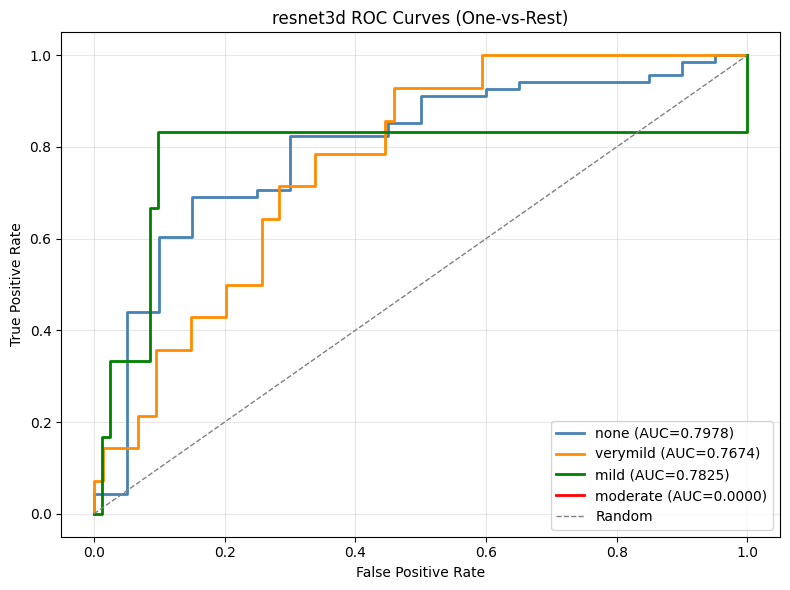

ROC curve saved to results_3d/resnet3d_roc_curve.pdf


/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


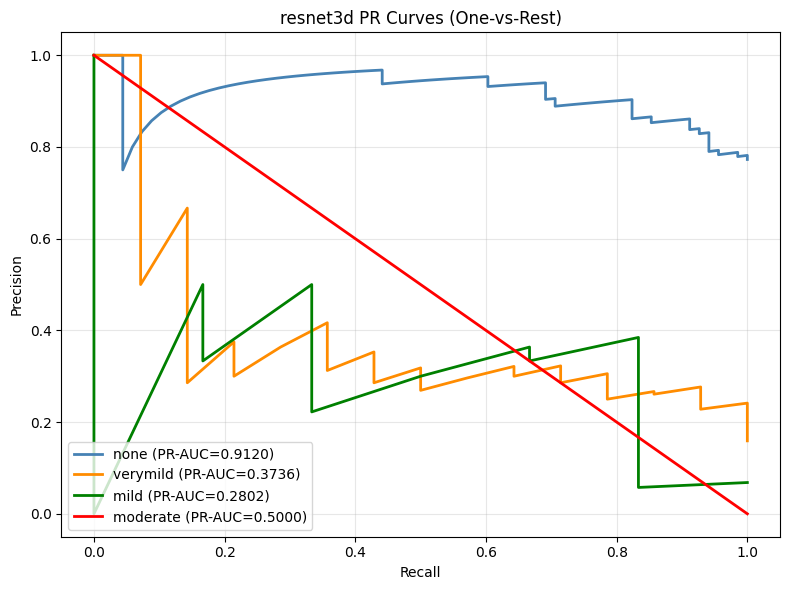

PR curve saved to results_3d/resnet3d_pr_curve.pdf


In [33]:
print('=== ResNet3D Evaluation ===')
resnet3d_pred, resnet3d_true, resnet3d_scores = model_sum(
    model=resnet3d_model, model_str='resnet3d', val_loader=val_loader, device=device
)

=== SimpleCNN3D Evaluation ===
Accuracy:        0.8182
Precision (macro): 0.7995
Recall (macro):    0.5738
F1 (macro):        0.5844

Per-class F1:
  none: 0.9051
  verymild: 0.5625
  mild: 0.2857
  moderate: 0.0000

Confusion Matrix:
          none  verymild  mild
none        62         6     0
verymild     5         9     0
mild         2         3     1
Saved to results_3d/simple3d_confusion_matrix.csv


/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


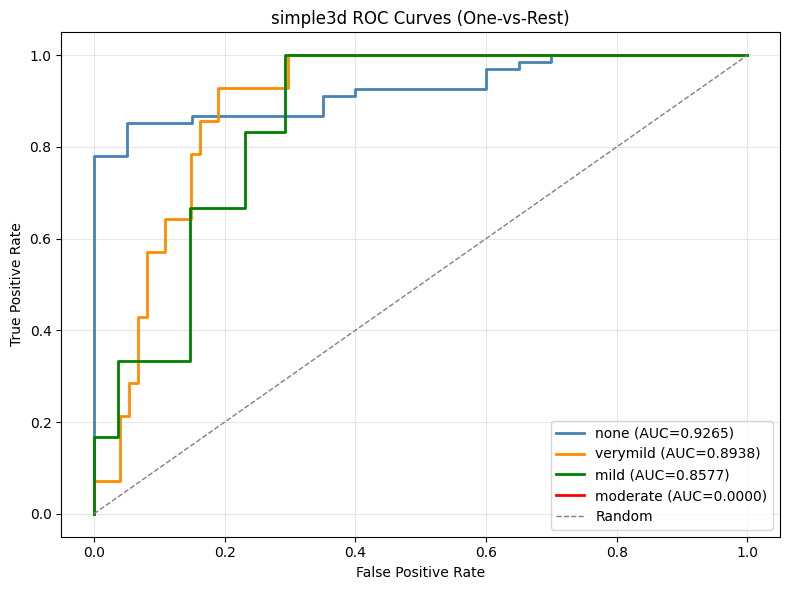

ROC curve saved to results_3d/simple3d_roc_curve.pdf


/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


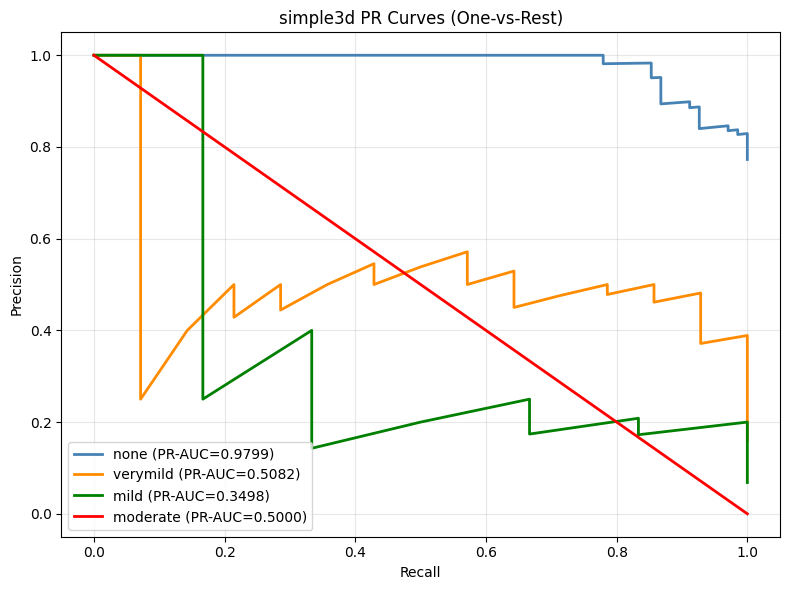

PR curve saved to results_3d/simple3d_pr_curve.pdf


In [34]:
print('=== SimpleCNN3D Evaluation ===')
simple3d_pred, simple3d_true, simple3d_scores = model_sum(
    model=simple3d_model, model_str='simple3d', val_loader=val_loader, device=device
)

/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/soheilgolara/soheil_env/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


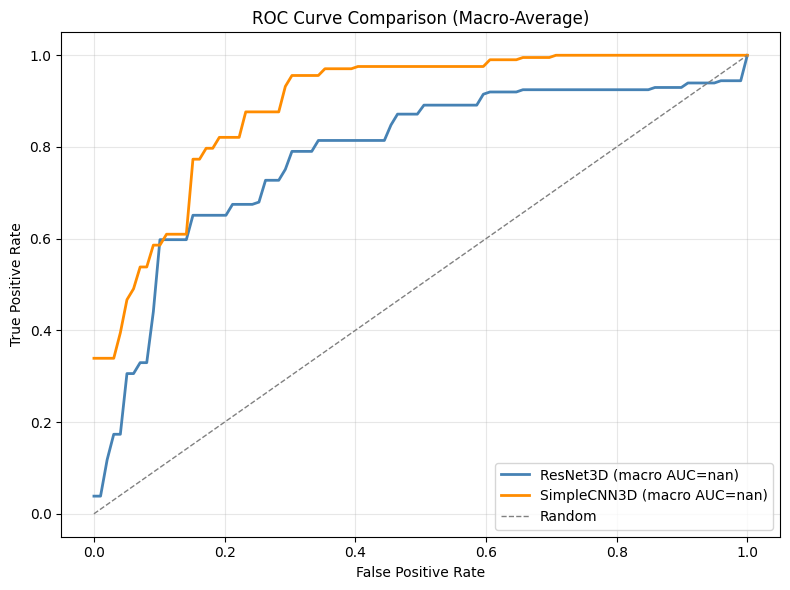

Saved to results_3d/roc_curve_comparison.pdf


In [35]:
def plot_roc_comparison(model1, name1, model2, name2, dataloader, device):
    """Plot macro-average ROC comparison between two models."""
    results = []
    for model, name in [(model1, name1), (model2, name2)]:
        y_pred, y_true, y_scores = eval_model(model, dataloader, device)
        # Macro-average ROC: average across classes
        fpr_all, tpr_all = [], []
        for i in range(NUM_CLASSES):
            if y_true[:, i].sum() > 0:
                fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
                fpr_all.append(fpr)
                tpr_all.append(tpr)
        # Compute macro-average AUC
        macro_auc = roc_auc_score(y_true, y_scores, average='macro', multi_class='ovr')
        results.append((fpr_all, tpr_all, macro_auc, name))

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['steelblue', 'darkorange']
    for (fpr_all, tpr_all, macro_auc, name), color in zip(results, colors):
        # Plot mean ROC
        mean_fpr = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(mean_fpr)
        for fpr, tpr in zip(fpr_all, tpr_all):
            mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr /= len(fpr_all)
        ax.plot(mean_fpr, mean_tpr, color=color, lw=2, label=f'{name} (macro AUC={macro_auc:.4f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve Comparison (Macro-Average)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'roc_curve_comparison.pdf')
    plt.savefig(path)
    plt.show()
    print(f'Saved to {path}')

plot_roc_comparison(resnet3d_model, 'ResNet3D', simple3d_model, 'SimpleCNN3D', val_loader, device)

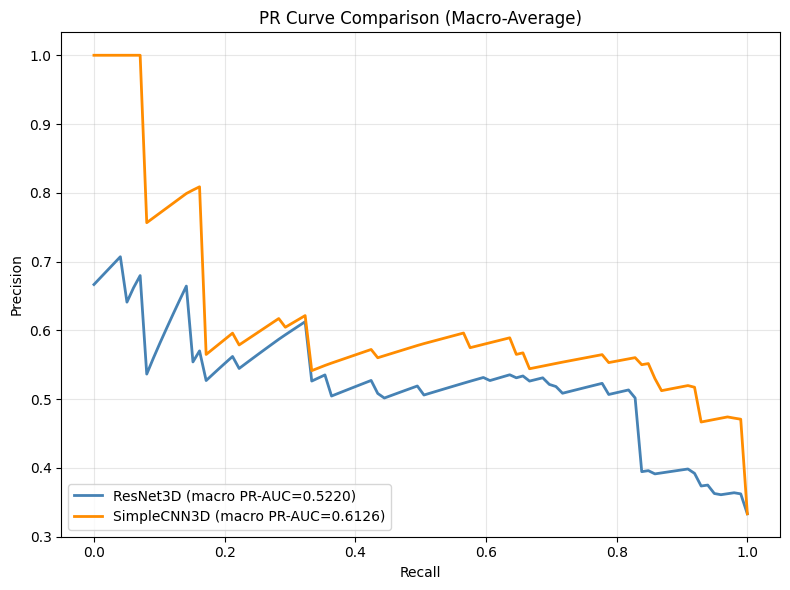

Saved to results_3d/pr_comparison.pdf


In [36]:
def plot_pr_comparison(model1, name1, model2, name2, dataloader, device):
    """Plot macro-average PR comparison between two models."""
    results = []
    for model, name in [(model1, name1), (model2, name2)]:
        y_pred, y_true, y_scores = eval_model(model, dataloader, device)
        pr_aucs = []
        recalls_all, precisions_all = [], []
        for i in range(NUM_CLASSES):
            if y_true[:, i].sum() > 0:
                precs, recs, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
                pr_aucs.append(auc(recs, precs))
                recalls_all.append(recs)
                precisions_all.append(precs)
        macro_pr_auc = np.mean(pr_aucs)
        results.append((recalls_all, precisions_all, macro_pr_auc, name))

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['steelblue', 'darkorange']
    for (recalls_all, precisions_all, macro_pr_auc, name), color in zip(results, colors):
        mean_recall = np.linspace(0, 1, 100)
        mean_precision = np.zeros_like(mean_recall)
        for recs, precs in zip(recalls_all, precisions_all):
            mean_precision += np.interp(mean_recall, recs[::-1], precs[::-1])
        mean_precision /= len(recalls_all)
        ax.plot(mean_recall, mean_precision, color=color, lw=2, label=f'{name} (macro PR-AUC={macro_pr_auc:.4f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('PR Curve Comparison (Macro-Average)')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'pr_comparison.pdf')
    plt.savefig(path)
    plt.show()
    print(f'Saved to {path}')

plot_pr_comparison(resnet3d_model, 'ResNet3D', simple3d_model, 'SimpleCNN3D', val_loader, device)

In [37]:
elapsed = time.time() - _START_RUNTIME
print(f'\nTotal runtime: {elapsed/60:.1f} minutes')


Total runtime: 2506.0 minutes
